Mi respuesta a preguntas del tp que estan en el medio del codigo

- Q3) Es para calcular la frecuencia absoluta de cada label
- Q4) Podria, pero la implementacion de _fit_params usa a_priori, asi que se deberia reescribir parte del codigo
- Q5) El masking debe ser un vector no una matriz de una columna/fila
- Q6) Pq nuestra implementacion utiliza el estimador de max likelihood
- Q7) Pq queremos la media muestral de cada feature para cada label, no la media de la observacion para cada label

___

In [2]:
# imports
import numpy as np
import numpy.linalg as LA

from base.qda import QDA, TensorizedQDA
from base.cholesky import QDA_Chol1, QDA_Chol2, QDA_Chol3
from utils.bench import Benchmark
from utils.datasets import (get_iris_dataset, get_letters_dataset, 
                            get_penguins_dataset, get_wine_dataset,
                            label_encode)
import matplotlib.pyplot as plt

1. ¿Sobre qué paraleliza `TensorizedQDA`? ¿Sobre las $k$ clases, las $n$ observaciones a predecir, o ambas?

Paraleliza sobre las clases, ya que evita el for loop antes usado en predict_one. Aun asi, el metodo predict no se modifica y este tanto en QDA como en TensorizedQDA usa un for loop para iterar en cada sample

___

2. Analizar los shapes de `tensor_inv_covs` y `tensor_means` y explicar paso a paso cómo es que `TensorizedQDA` llega a predecir lo mismo que `QDA`.

In [3]:
X_full, y_full = get_wine_dataset()
y_full_encoded = label_encode(y_full)
print(f"Shape de X -> {X_full.shape} | Shape de Y -> {y_full_encoded.shape}")

Shape de X -> (178, 13) | Shape de Y -> (178, 1)


In [4]:
X_full, y_full = get_wine_dataset()

tqda = TensorizedQDA()
tqda.fit(X_full.T,y_full_encoded.T)

print(f"Shape de tensor_inv_covs -> {tqda.tensor_inv_cov.shape}")
print(f"Shape de tensor_means -> {tqda.tensor_means.shape}")

Shape de tensor_inv_covs -> (3, 13, 13)
Shape de tensor_means -> (3, 13, 1)


Los shapes de estos tensores se pueden entender como que el primer indice selecciona una clase en parrticular. En el caso de la matriz inversa de covarianza el segundo y tercer indice hacen referencia a los elementos de la matriz de covarianza. Por otro lado, el de las medias se puede entender como una matriz de una columna donde cada fila reprresenta la media de cada feature.

Llegan a la misma solucion ya que hacen un camino similar parteindo del metodo predict, con la diferencia en la implementacion de `predict_one`. En el de QDA en un for loop hace la estimacion iterando en cada clase, llamando de uno a uno al metodo `_predict_log_conditional`. Por otro lado, en TensorizedQDA se reemplimenta `predict_one` haciendo un unico llamado a `_predict_log_conditional` en donde el calculo se hace con los tensores. En este caso, numpy al hacer operaciones entre matrices y tensores la replica en las dimensiones faltantes. Por ej cuando se hace `x - self.tensor_means`, donde x es de Nx1 y self_tensor_means es de KxNx1  se replica la resta de las matrices Nx1 en las K dimensiones. Algo similar pasa con la otra operacion, en donde se ajusta la trnaspuesta para que tome efecto en las matrices asociadas a cada label y se calcula de forma similar, con la precaucion de que ahora el determinate calculado tiene forma de un vector por lo que se ajusta el producto matricial para que las dimensiones coincidan.

___


3. Implementar el modelo `FasterQDA` (se recomienda heredarlo de `TensorizedQDA`) de manera de eliminar el ciclo for en el método predict.

In [5]:
class FasterQDA(TensorizedQDA):
    def predict(self, X):

        unbiased_x = X - self.tensor_means
        inner_prod = unbiased_x.transpose(0,2,1) @ self.tensor_inv_cov @ unbiased_x
        diag_inner_prod = np.diagonal(inner_prod,axis1=1,axis2=2).T # Mantenemos solo la diagonal, transpongo para poder hacer los calculos
        log_cond = 0.5*np.log(LA.det(self.tensor_inv_cov)) - 0.5 * diag_inner_prod
        posteriori = self.log_a_priori + log_cond

        y_hat = np.argmax(posteriori,axis=1) # Probabilidades en columnas
    
        return y_hat.reshape(1,-1)


In [6]:
# Check rapido de implementacion

fqda = FasterQDA()
fqda.fit(X_full.T,y_full_encoded.T)

a = tqda.predict(X_full.T)
b = fqda.predict(X_full.T)

print(f"Son iguales: {(a==b).all()}")


Son iguales: True


___

4. Mostrar dónde aparece la mencionada matriz de $n \times n$, donde $n$ es la cantidad de observaciones a predecir.

Esta matriz aparece al hacer $$(X-\mu)^T \Sigma^{-1} (X- \mu)$$

En la implementacion de FasterQDA se observa en la variable `inner_prod`

___

5. Demostrar que
$$
diag(A \cdot B) = \sum_{cols} A \odot B^T = np.sum(A \odot B^T, axis=1)
$$ es decir, que se puede "esquivar" la matriz de $n \times n$ usando matrices de $n \times p$. También se puede usar, de forma equivalente,
$$
np.sum(A^T \odot B, axis=0).T
$$
___

6. Utilizar la propiedad antes demostrada para reimplementar la predicción del modelo `FasterQDA` de forma eficiente en un nuevo modelo `EfficientQDA`.

In [7]:
class EfficientQDA(FasterQDA):
    def predict(self, X):

        unbiased_x = X - self.tensor_means
        prod_1 = self.tensor_inv_cov @ unbiased_x # Primer parte del produucto grande
        diag_inner_prod = np.sum(unbiased_x.transpose(0,2,1) * prod_1.transpose(0,2,1), axis=2) #Aplico la propiedad, axis 2 serria las columnas
        log_cond = 0.5*np.log(LA.det(self.tensor_inv_cov)) - 0.5 * diag_inner_prod.T #Trasnpongo la diagonal para pdoer operar
        posteriori = self.log_a_priori + log_cond

        y_hat = np.argmax(posteriori,axis=1) # Probabilidades en columnas
    
        return y_hat.reshape(1,-1)

In [8]:
# Check rapido de implementacion

eqda = EfficientQDA()
eqda.fit(X_full.T,y_full_encoded.T)

a = tqda.predict(X_full.T)
b = eqda.predict(X_full.T)

print(f"Son iguales: {(a==b).all()}")

Son iguales: True


___

7. Comparar la performance de las 4 variantes de QDA implementadas hasta ahora (no Cholesky) ¿Qué se observa? A modo de opinión ¿Se condice con lo esperado?

In [9]:
b = Benchmark(
    X_full, y_full_encoded,
    n_runs = 100,
    warmup = 20,
    mem_runs = 20,
    test_sz = 0.3,
    same_splits = False
)
# bencheamos un par
to_bench = [QDA, TensorizedQDA, FasterQDA, EfficientQDA]

for model in to_bench:
    b.bench(model)

summ = b.summary()
summ[['train_median_ms', 'test_median_ms','mean_accuracy','train_mem_median_mb','test_mem_median_mb']]

Benching params:
Total runs: 140
Warmup runs: 20
Peak Memory usage runs: 20
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


QDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedQDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

FasterQDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

FasterQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

EfficientQDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

EfficientQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

,train_median_ms,test_median_ms,mean_accuracy,train_mem_median_mb,test_mem_median_mb
model,,,,,
QDA,0.344123,2.739656,0.982407,0.018456,0.007682
TensorizedQDA,0.348032,1.141795,0.982593,0.018456,0.012108
FasterQDA,0.375855,0.077546,0.985741,0.017860,0.109238
EfficientQDA,0.379020,0.084191,0.983333,0.018009,0.075287


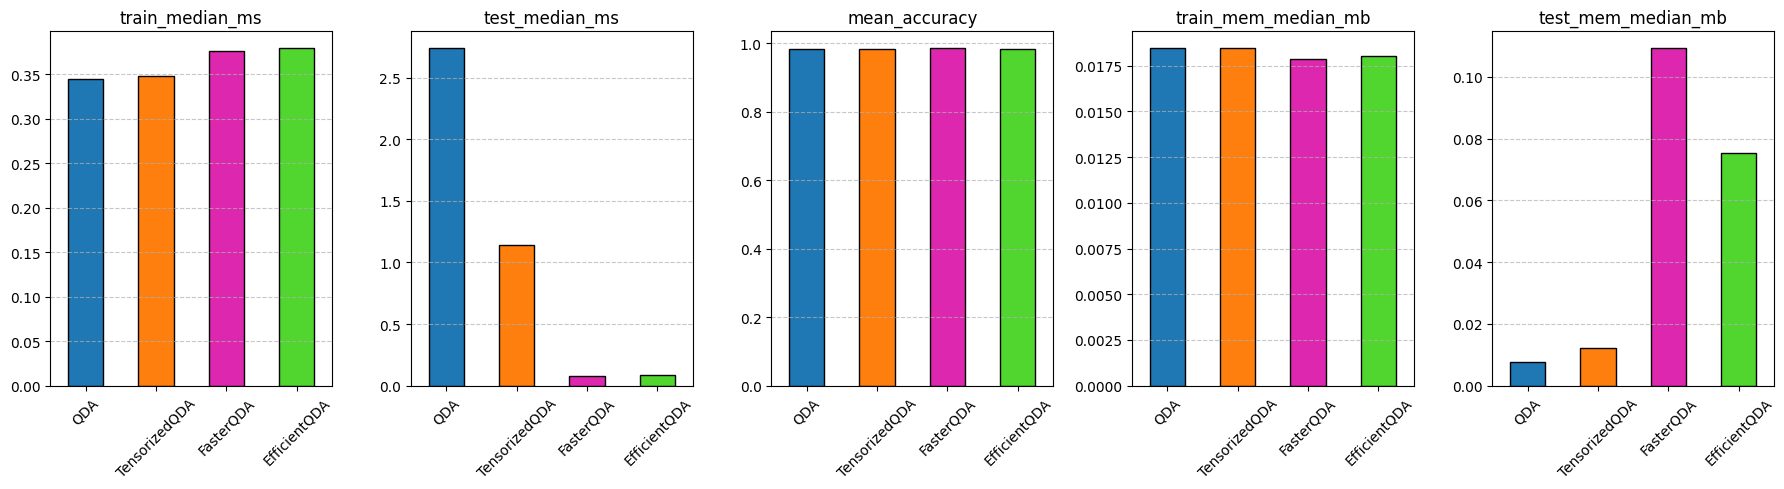

In [10]:
# Grafico para ver las metricas (100% hecho con IA)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
# axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

# Lista de las métricas que queremos graficar
features = [
    'train_median_ms', 
    'test_median_ms', 
    'mean_accuracy', 
    'train_mem_median_mb', 
    'test_mem_median_mb'
]

# 3. Iteramos sobre cada métrica para crear su gráfico de barras
for i, feature in enumerate(features):
    # Ploteamos directamente desde pandas seleccionando los colores
    summ[feature].plot(kind='bar', ax=axes[i], color=['#1f77b4', '#ff7f0e', "#dd27af","#50d62f"], edgecolor='black')
    
    # Ajustes estéticos (título, etiquetas, rotación del texto, grilla)
    axes[i].set_title(feature)
    axes[i].set_ylabel(None)
    axes[i].set_xlabel(None)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Eliminamos el último subplot (el sexto) ya que solo tenemos 5 features
# fig.delaxes(axes[5])

# 5. Ajustamos los márgenes para que no se superpongan los títulos
plt.tight_layout()

# Opcional: mostrar o guardar el gráfico
# plt.savefig('benchmark_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Observando las metricas de cada implementacion, observamos lo siguiente:
- En tiempo de entrenamiento hubo una ligera perdida al usar las versiones tensorizadas, creo yo atribuibles a armar el tensor al llamar al metodo `stack`
- Los tiempos de test bajaron drasticamente, lo cual es esperable. FasterQDA y EfficientQDA no tienen muchas diferencias ya que el cambio en estas implementaciones afecta directamente a la memoria
- El accuracy se mantuvo, cosa que es razonable ya que el modelo de fondo sigue siendo el mismo.
- El consumo de memoria en entrenaiento es similar para todas. Lo que en cierto sentido es esperable ya que en ningun metodo quitamos o agregamos nada, simplemente reordenamos informacion en las versiones tensorizadas, pero partiendo de los mismos datos.
- El consumo de memoria en test si varia. Si tomamos como baseline a TensorizedQDA vemos que esta empeora mucho al hacer la prediccion simultanea de todas las observaciones en FasterQDA, atribuido directamente a la matriz de NxN que se debe calcular. Tambien observamos como al esquivar esa matriz con las propiedades del punto anterior, utilizando EfficientQDA, este consumo baja aproximadamente un 35%
___

8. Si una matriz $A$ tiene fact. de Cholesky $A=LL^T$, expresar $A^{-1}$ en términos de $L$. ¿Cómo podría esto ser útil en la forma cuadrática de QDA?

Partimos de:
$$A = LL^T$$
aplicamos inversa en ambos lados
$$A^{-1} = (LL^T)^{-1}$$
Aplciamos la propiedad $(AB)^{-1} = B^{-1} A^{-1}$
$$A^{-1} = (L^{T})^{-1} L^{-1}$$
Aplicamos la propiedad $(A^{-1})^{T} = (A^{T})^{-1}$
$$A^{-1} = (L^{-1})^{T} L^{-1}$$

Entendiendo que el caluclo de la inversa de L es simple ya que es triangular y que a su vez el producto de 2 matrices triangulares tambien es simple. Podemos decir que esta forma de calcular la inversa de la matriz original es mas eficiente por esta via.

La utilidad en el contexto del TP radica en la necesidad de calcular la inversa de la matriz de covarianza, que sabemos que es simetrica y definida positiva, por lo que admite descomposicion de cholesky
___

9. Explicar las diferencias entre `QDA_Chol1`y `QDA` y cómo `QDA_Chol1` llega, paso a paso, hasta las predicciones.

Las diferencias entre  estas implmentaciones estan en la forma en que se hace el entramiento y la prediccion. A diferencia de la implementacion QDA, QDA_Chol1 no utiliza directamente la matriz de covariazas, sino que hace uso de su factorizacion de cholesky. Luego para la prediccion, la version con Cholesky calcula el determinante aplicando varias propiedades, como:
$$det(A) = det(A^T)$$
$$det(A^{-1}) = 1/det(A)$$
$$log(1/A) = -log(A)$$
$$det(AB) = det(A) det(B)$$
$$det(L) = \prod L_{ii} \space \text{donde L es triangular}$$
Tras aplicar todo eso podemos desarrollar la primer parte de la prediccion como:
$$
-0.5 log(|\Sigma|) \rightarrow 0.5 log(1/(|\Sigma^{-1}|)) \rightarrow 0.5 log(|\Sigma^{-1}|)
$$
$$
0.5 log(|LL^{T}|) \rightarrow 0.5 log(|L||L^{T}|) \rightarrow 0.5 log(|L||L|) \rightarrow 0.5 (log|L| + log|L|) \rightarrow log|L|
$$
$$
log(\prod L_{ii}) 
$$

Con respecto a la segunda parte, se aplican propiedades como:
$$(AB)^{T} = B^{T}A^{T}$$
$$(A^{-1})^{T} = (A^{T})^{-1}$$
$$A^{T}B^{T} = (BA)^{T}$$
$$y^{T}y = \sum y_i^{2} \space \text{Siendo y un vector}$$
Resolviendo
$$
(x-\mu)^{T}\Sigma^{-1}(x-\mu)
$$
$$
(x-\mu)^{T}(LL^{T})^{-1}(x-\mu)
$$
$$
(x-\mu)^{T}[(L^{T})^{-1}L^{-1}](x-\mu)
$$
$$
(x-\mu)^{T}[(L^{-1})^{T}L^{-1}](x-\mu)
$$
$$
((x-\mu)^{T}(L^{-1})^{T})(L^{-1}(x-\mu))
$$
$$
(L^{-1}(x-\mu))^{T}(L^{-1}(x-\mu))
$$
$$
\text{Definimos} \rightarrow (L^{-1}(x-\mu)) = y
$$
$$
y^{T}y
$$
$$
\sum y_i^{2}
$$

En sinteis, la version con Cholesky hace las mismas cuentas pero aplicando propiedades se llega a una version mas ligera. Pasamos de:
$$\log{f(x)} = -\frac{1}{2}\log |\Sigma| - \frac{1}{2} (x-\mu)^T \Sigma^{-1} (x- \mu)$$
a
$$\log{f(x) = \log{\prod L_{ii}} + 0.5  \sum y_i^{2} }$$
___

10. ¿Cuáles son las diferencias entre `QDA_Chol1`, `QDA_Chol2` y `QDA_Chol3`?

La implementacion 1 tiene la particularidad de utilizar directamente la inversa de la matriz triangular de cholesky.

Por otro lado, la 2 usa la matriz de cholesky sin invertir, lo que implica que se modifica ligeramente el termino del determinante considerando las propiedades de que el determinante de la inversa es la inversa del determinante de la matriz sin invertir y la propiedad de que el logaritmo de un cociente es la resta de los logaritmos del numerador y el denominador. Por otro lado, calcula el vector `y` de forma distinta, considerando que $A^{-1}b$ equivale a resolver el sistema $Ax=b$, donde $A=L$ y $b=(x-\mu)$. Usa la funcion `solve_triangular` que es funciona para matrices triangulares, como en este caso, y es mas rapida.

Finalmente, la ultima implementacion es muy similar a la primera, con la salvedad de que utiliza la funcion `dtrtri` para el calculo de la inversa ya que aprovecha el hecho de que esta matriz es triangular, lo que optimiza el calculo.

___

11. Comparar la performance de las 7 variantes de QDA implementadas hasta ahora ¿Qué se observa?¿Hay alguna de las implementaciones de `QDA_Chol` que sea claramente mejor que las demás?¿Alguna que sea peor?



In [49]:
b = Benchmark(
    X_full, y_full_encoded,
    n_runs = 100,
    warmup = 20,
    mem_runs = 20,
    test_sz = 0.3,
    same_splits = False
)
# bencheamos un par
to_bench = [QDA, TensorizedQDA, FasterQDA, EfficientQDA,QDA_Chol1,QDA_Chol2,QDA_Chol3]

for model in to_bench:
    b.bench(model)

summ = b.summary()
summ[['train_median_ms', 'test_median_ms','mean_accuracy','train_mem_median_mb','test_mem_median_mb']]

Benching params:
Total runs: 140
Warmup runs: 20
Peak Memory usage runs: 20
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


QDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedQDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

...

QDA_Chol2 (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

QDA_Chol2 (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

QDA_Chol3 (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

QDA_Chol3 (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

,train_median_ms,test_median_ms,mean_accuracy,train_mem_median_mb,test_mem_median_mb
model,,,,,
QDA,0.341789,2.724165,0.982407,0.018364,0.007545
TensorizedQDA,0.496349,1.504231,0.982593,0.018364,0.011971
FasterQDA,0.416030,0.096418,0.985741,0.017769,0.109100
EfficientQDA,0.430615,0.098516,0.983333,0.017918,0.075150
QDA_Chol1,0.503737,1.801708,0.986111,0.017937,0.007751
QDA_Chol2,0.369425,4.799235,0.982222,0.017956,0.007968
QDA_Chol3,0.406762,1.662939,0.984444,0.017704,0.007622


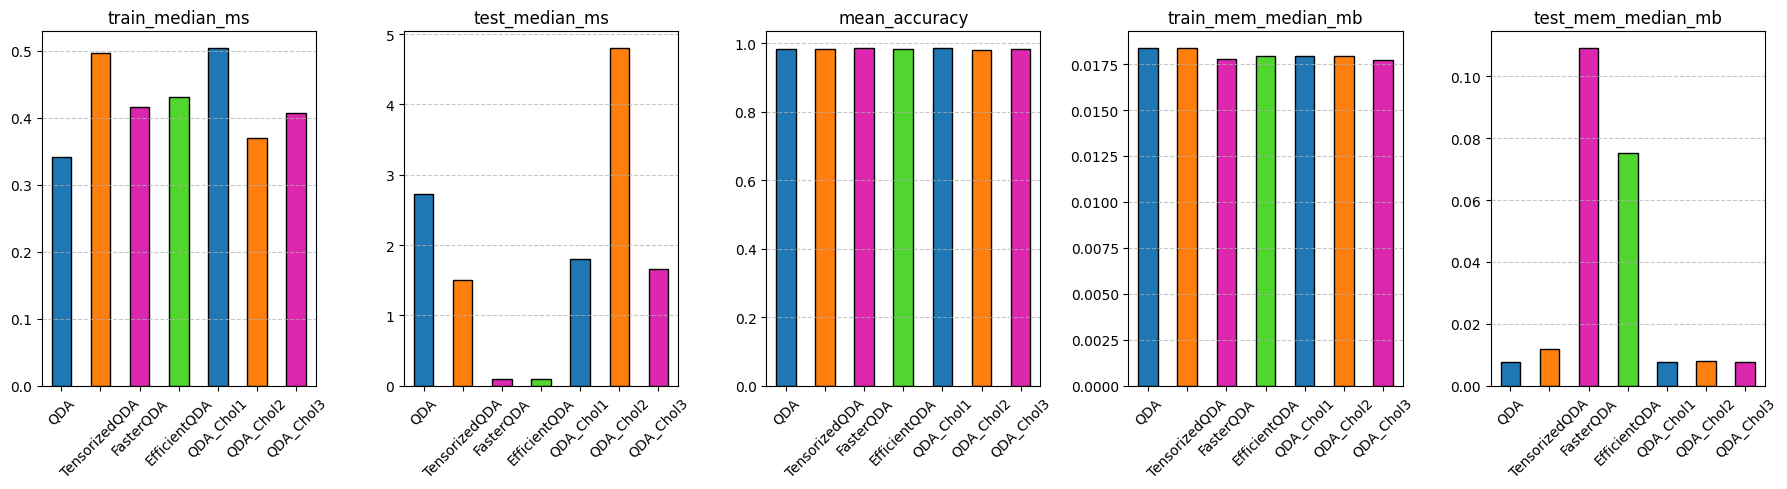

In [50]:
# Grafico para ver las metricas (100% hecho con IA)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
# axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

# Lista de las métricas que queremos graficar
features = [
    'train_median_ms', 
    'test_median_ms', 
    'mean_accuracy', 
    'train_mem_median_mb', 
    'test_mem_median_mb'
]

# 3. Iteramos sobre cada métrica para crear su gráfico de barras
for i, feature in enumerate(features):
    # Ploteamos directamente desde pandas seleccionando los colores
    summ[feature].plot(kind='bar', ax=axes[i], color=['#1f77b4', '#ff7f0e', "#dd27af","#50d62f"], edgecolor='black')
    
    # Ajustes estéticos (título, etiquetas, rotación del texto, grilla)
    axes[i].set_title(feature)
    axes[i].set_ylabel(None)
    axes[i].set_xlabel(None)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Eliminamos el último subplot (el sexto) ya que solo tenemos 5 features
# fig.delaxes(axes[5])

# 5. Ajustamos los márgenes para que no se superpongan los títulos
plt.tight_layout()

# Opcional: mostrar o guardar el gráfico
# plt.savefig('benchmark_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Al comparar las 7 entre si, podemos ver que las versiones tensorizadas con predicciones simultaneas siguen siendo las mas rapidas al corrrer el dataset de prueba a expensas de mayor consumo de memoria. Se observa nuevamnete que la memoria de entrenamiento y la precision presentan valores similares en todos los modelos.

Por otro lado, comparando solo las versiones con cholesky vemos como la primera es mas lenta para entrenmiento, lo cual puede ser razonable, considerando que la segunda implementacion evita una inversa y la tercera la calcula con una funcion optimizada para matrices triangulares. Por otro lado a la hora de predecir, la primer y tercer son mas rapidas, debido a que supone menos esfuerzo el calculo del prodcuto matricial entre la matriz triangular inversa y el desvio respecto de la media que el calculo resolviendo el sistema de ecuaciones.

Respecto de si hay mejores y peores, podemos decir que la tercer implementacion es mas rapida en train y test sin comprometer el uso de memoria asi que desde ese aspecto es objetivamente mejor. Por otro lado, no hay una peor ya que al comparar la primera con la segunda tenemos ganancias de tiempo en train o test asi que dependera de la aplicacion en concreto

___

12. Implementar el modelo `TensorizedChol` paralelizando sobre clases/observaciones según corresponda. Se recomienda heredarlo de alguna de las implementaciones de `QDA_Chol`, aunque la elección de cuál de ellas queda a cargo del alumno según lo observado en los benchmarks de puntos anteriores.

In [13]:
class TensorizedChol(QDA_Chol3):
    def _fit_params(self, X, y):
        super()._fit_params(X,y)
        #Armamos los tensores
        self.tensor_L_invs = np.stack(self.L_invs) 
        self.tensor_means = np.stack(self.means)

    def _predict_log_conditionals(self,x):
        unbiased_x = x - self.tensor_means 
        y = self.tensor_L_invs @ unbiased_x
        #Mucho cuidado al seleccionar dimensiones
        #en el caso del determinante, se debe seleccionar la submatriz del tensor
        #que esta compuesta por los ejes 1 y 2 que representan las labels y los features
        #luego se debe calcuular el producto de las columnas de esta nueva matriz, que 
        #es la que representa los features

        #Similar con la otra parte, se debe hacer la suma sobre las columnas
        #ya que representa las features
        return np.log(self.tensor_L_invs.diagonal(axis1=1,axis2=2).prod(axis=1)) -0.5 * (y**2).sum(axis=1).flatten()

    def _predict_one(self, x):
        #Esto se mantiene igual que en TensorizedQDA
        return np.argmax(self.log_a_priori + self._predict_log_conditionals(x))

In [14]:
# Check rapido de implementacion

tchol = TensorizedChol()
tchol.fit(X_full.T,y_full_encoded.T)

a = tqda.predict(X_full.T)
b = tchol.predict(X_full.T)

print(f"Son iguales: {(a==b).all()}")

Son iguales: True


___

13. Implementar el modelo `EfficientChol` combinando los insights de `EfficientQDA` y `TensorizedChol`. Si se desea, se puede implementar `FasterChol` como ayuda, pero no se contempla para el punto.

In [ ]:
class EfficientChol(TensorizedChol):
    def predict(self, X):
        unbiased_x = X - self.tensor_means
        y_t = (unbiased_x.transpose(0,2,1) @ self.tensor_L_invs.transpose(0,2,1)) #Hacemos el calculo de y_t 
        
        diag = np.sum((y_t**2),axis=2) #calculo la diagonal aplicando la propiedad de antes y ahora hago provecho de que el producto tiene la forma yT.y
        det = np.log(self.tensor_L_invs.diagonal(axis1=1,axis2=2).prod(axis=1)) #Calculo la parte del det como se hacia en chol3
        log_cond = det -0.5 * diag.T 
        posteriori = self.log_a_priori + log_cond #Calculo las probalilidad

        y_hat = np.argmax(posteriori,axis=1) #Selecciono la mayot, probabilidades en columnas    
        return y_hat.reshape(1,-1)


In [43]:
# Check rapido de implementacion

echol = EfficientChol()
echol.fit(X_full.T,y_full_encoded.T)

a = tqda.predict(X_full.T)
b = echol.predict(X_full.T)

print(f"Son iguales: {(a==b).all()}")

Son iguales: True


___

14. Comparar la performance de las 9 variantes de QDA implementadas ¿Qué se observa? A modo de opinión ¿Se condice con lo esperado?

In [51]:
b = Benchmark(
    X_full, y_full_encoded,
    n_runs = 100,
    warmup = 20,
    mem_runs = 20,
    test_sz = 0.3,
    same_splits = False
)
# bencheamos un par
to_bench = [QDA, TensorizedQDA, FasterQDA, EfficientQDA,QDA_Chol1,QDA_Chol2,QDA_Chol3,TensorizedChol,EfficientChol]

for model in to_bench:
    b.bench(model)

summ = b.summary()
summ[['train_median_ms', 'test_median_ms','mean_accuracy','train_mem_median_mb','test_mem_median_mb']]

Benching params:
Total runs: 140
Warmup runs: 20
Peak Memory usage runs: 20
Running time runs: 100
Train size rows (approx): 125
Test size rows (approx): 53
Test size fraction: 0.3


QDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

QDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

TensorizedQDA (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

TensorizedQDA (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

...

TensorizedChol (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

TensorizedChol (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

EfficientChol (MEM):   0%|          | 0/20 [00:00<?, ?it/s]

EfficientChol (TIME):   0%|          | 0/100 [00:00<?, ?it/s]

,train_median_ms,test_median_ms,mean_accuracy,train_mem_median_mb,test_mem_median_mb
model,,,,,
QDA,0.359938,2.809106,0.982407,0.018364,0.007589
TensorizedQDA,0.423594,1.360497,0.982593,0.018364,0.011971
FasterQDA,0.322314,0.068545,0.985741,0.017769,0.109100
EfficientQDA,0.522875,0.110842,0.983333,0.017918,0.075150
QDA_Chol1,0.522250,1.747809,0.986111,0.017937,0.007751
QDA_Chol2,0.345878,4.435761,0.982222,0.017853,0.007968
QDA_Chol3,0.357120,1.523582,0.984444,0.017658,0.007622
TensorizedChol,0.540739,1.223822,0.986667,0.017956,0.012436
EfficientChol,0.371281,0.065372,0.985556,0.018105,0.060165


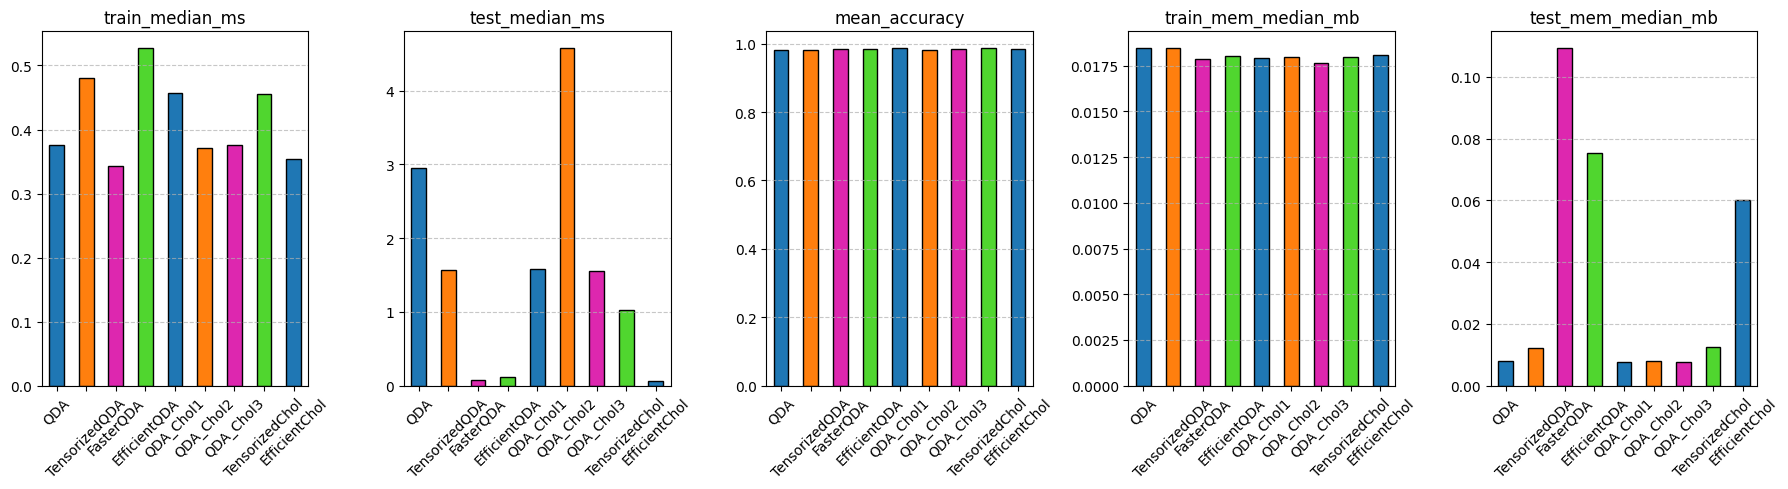

In [48]:
# Grafico para ver las metricas (100% hecho con IA)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
# axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

# Lista de las métricas que queremos graficar
features = [
    'train_median_ms', 
    'test_median_ms', 
    'mean_accuracy', 
    'train_mem_median_mb', 
    'test_mem_median_mb'
]

# 3. Iteramos sobre cada métrica para crear su gráfico de barras
for i, feature in enumerate(features):
    # Ploteamos directamente desde pandas seleccionando los colores
    summ[feature].plot(kind='bar', ax=axes[i], color=['#1f77b4', '#ff7f0e', "#dd27af","#50d62f"], edgecolor='black')
    
    # Ajustes estéticos (título, etiquetas, rotación del texto, grilla)
    axes[i].set_title(feature)
    axes[i].set_ylabel(None)
    axes[i].set_xlabel(None)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Eliminamos el último subplot (el sexto) ya que solo tenemos 5 features
# fig.delaxes(axes[5])

# 5. Ajustamos los márgenes para que no se superpongan los títulos
plt.tight_layout()

# Opcional: mostrar o guardar el gráfico
# plt.savefig('benchmark_summary.png', dpi=300, bbox_inches='tight')
plt.show()